# 定义一些可能出错的情况
不可能一直顺序执行

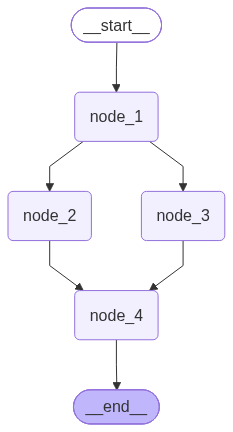

1k:logs v:['START']
1k:cur_id v:start
3k:logs v:['START', 'node_1 运行完毕']
3k:cur_id v:start
2k:logs v:['START', 'node_1 运行完毕']
2k:cur_id v:start
4k:logs v:['START', 'node_1 运行完毕', 'node_2 运行完毕', 'node_3 运行完毕']
4k:cur_id v:start
============================== -> result <- ==============================
{'logs': ['START', 'node_1 运行完毕', 'node_2 运行完毕', 'node_3 运行完毕', 'node_4 运行完毕'], 'cur_id': 'start'}


In [16]:
from sys import displayhook
from typing import TypedDict,Annotated
from operator import add
from time import sleep

from langgraph import graph
from langgraph.graph import StateGraph,START,END
from langgraph.types import Overwrite


# 1. 定义状态
class OverAllState(TypedDict):
    # 归约的方式是add追加合并
    logs:Annotated[list[str],add]
    cur_id: str


# 2. 定义节点
def node_1(state:OverAllState) -> OverAllState:
    for k,v in state.items():
        print(f"1k:{k} v:{v}")
    return {
        "logs":["node_1 运行完毕"]
    }

def node_2(state:OverAllState) -> OverAllState:
    # sleep(1)
    for k,v in state.items():
        print(f"2k:{k} v:{v}")
    return {
        "logs":["node_2 运行完毕"]
    }

def node_3(state:OverAllState) -> OverAllState:
    sleep(1)
    for k,v in state.items():
        print(f"3k:{k} v:{v}")
    return {
        "logs":["node_3 运行完毕"]
    }

def node_4(state:OverAllState) -> OverAllState:
    sleep(2)  # 调控执行顺序， 先 2 再 3 最后 4
    for k,v in state.items():
        print(f"4k:{k} v:{v}")
    return {
        "logs":["node_4 运行完毕"]
    }


builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_1", node_1) # 有重载写法 见下面
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)
builder.add_node("node_4", node_4)

builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_1", "node_3")
builder.add_edge("node_2", "node_4")
builder.add_edge("node_3", "node_4") # 3延迟执行，但是拿到的还是快照结果只有1
builder.add_edge("node_4", END)

graph = builder.compile()
display(graph)

result = graph.invoke({"logs": ["START"], "cur_id": "start"})
print('=' * 30, '-> result <-', '=' * 30)
print(result)


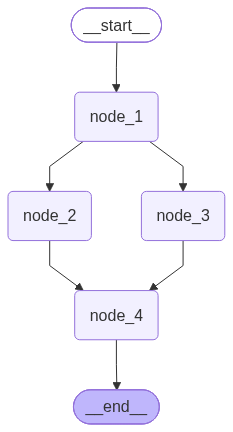

1k:logs v:['START']
1k:cur_id v:start
3k:logs v:['START', 'node_1 运行完毕']
3k:cur_id v:start
2k:logs v:['START', 'node_1 运行完毕']
2k:cur_id v:start
4k:logs v:['START', 'node_1 运行完毕', 'node_2 运行完毕', 'node_3 运行完毕']
4k:cur_id v:start
============================== -> result <- ==============================
{'logs': ['START', 'node_1 运行完毕', 'node_2 运行完毕', 'node_3 运行完毕', 'node_4 运行完毕'], 'cur_id': 'start'}


In [19]:
from sys import displayhook
from typing import TypedDict,Annotated
from operator import add
from time import sleep

from langgraph import graph
from langgraph.graph import StateGraph,START,END
from langgraph.types import Overwrite


# 1. 定义状态
class OverAllState(TypedDict):
    # 归约的方式是add追加合并
    logs:Annotated[list[str],add]
    cur_id: str


# 2. 定义节点
def node_1(state:OverAllState) -> OverAllState:
    for k,v in state.items():
        print(f"1k:{k} v:{v}")
    return {
        "logs":["node_1 运行完毕"]
    }

def node_2(state:OverAllState) -> OverAllState:
    sleep(1)
    for k,v in state.items():
        print(f"2k:{k} v:{v}")
    return {
        "logs":["node_2 运行完毕"]
    }

def node_3(state:OverAllState) -> OverAllState:
    # sleep(1)
    for k,v in state.items():
        print(f"3k:{k} v:{v}")
    return {
        "logs":["node_3 运行完毕"]
    }

def node_4(state:OverAllState) -> OverAllState:
    sleep(2)  # 调控执行顺序， 先 2 再 3 最后 4
    for k,v in state.items():
        print(f"4k:{k} v:{v}")
    return {
        "logs":["node_4 运行完毕"]
    }


builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_1", node_1) # 有重载写法 见下面
builder.add_node("node_3", node_3)
builder.add_node("node_2", node_2)
builder.add_node("node_4", node_4)

builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_3")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", "node_4")
builder.add_edge("node_3", "node_4") # 3延迟执行，但是拿到的还是快照结果只有1
builder.add_edge("node_4", END)

graph = builder.compile()
display(graph)

result = graph.invoke({"logs": ["START"], "cur_id": "start"})
print('=' * 30, '-> result <-', '=' * 30)
print(result) # 还是不能修改成 1 3 2 4，不知道原理
#TODO


好问题！直接回答：

## 不改边的情况下，无法实现

因为 `node_4` 有两条入边：
```
node_2 → node_4
node_3 → node_4
```

**LangGraph 的语义是：一个节点有多个入边时，必须等所有上游节点都完成才能执行。** 这是 DAG（有向无环图）的**固有特性**，不是 LangGraph 的限制。

所以当前结构下，执行顺序**必然**是：
```
node_1 → (node_2 ∥ node_3) → node_4 → END
```
`node_4` 永远不可能在 `node_3` 之前执行。

## 那为什么说"不固定"？

**LangGraph 的执行顺序不是固定的 1→2→3→4**，而是由**图的结构（边）** 决定的：

| 图的边结构 | 执行顺序 |
|:---|:---|
| 1→2→3→4 | 顺序：1→2→3→4 |
| 1→2, 1→3, 2→4, 3→4 | 并行+同步屏障：1→(2∥3)→4 |
| 1→2, 2→4, 4→3, 3→END | 顺序：1→2→4→3 |
| 1→2, 1→3, 2→4, 3→END, 4→END | 独立并行：1→(2∥3), 且2→4独立于3 |

## 用一句话总结

> **在 LangGraph 中，执行顺序 = 边的连接方式。** sleep 只能控制**速度**（谁先跑完），但无法改变**谁等谁**（依赖关系）。想让 `node_4` 在 `node_3` 之前执行，就必须去掉 `node_3 → node_4` 这条边。

所以你想实现目标顺序，最简洁的方案就是**去掉 `node_3 → node_4` 这条边**，让 `node_3` 独立走完：

```python
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_1", "node_3")    # 保留并行
builder.add_edge("node_2", "node_4")    # node_4 只依赖 node_2
builder.add_edge("node_3", END)         # node_3 独立到 END
builder.add_edge("node_4", END)         # node_4 独立到 END
```

这样 `node_2` 和 `node_3` 仍然是并行结构，但 `node_4` 不再等 `node_3`。

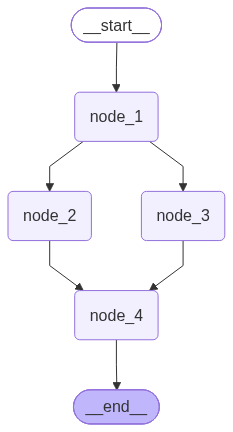

1k:logs v:['START']
1k:cur_id v:start
2k:logs v:['START', 'node_1 运行完毕']
2k:cur_id v:start
3k:logs v:['START', 'node_1 运行完毕']
3k:cur_id v:start


InvalidUpdateError: At key 'cur_id': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE

In [21]:
# 报错场景， 如果没有设置reducer， 在节点上出现值不一致的地方，就会报错，下面用cur_id举例子
from sys import displayhook
from typing import TypedDict,Annotated
from operator import add
from time import sleep

from langgraph import graph
from langgraph.graph import StateGraph,START,END
from langgraph.types import Overwrite


# 1. 定义状态
class OverAllState(TypedDict):
    # 归约的方式是add追加合并
    logs:Annotated[list[str],add]
    cur_id: str
    # cur_id: Annotated[str, add] # 这个不报错


# 2. 定义节点
def node_1(state:OverAllState) -> OverAllState:
    for k,v in state.items():
        print(f"1k:{k} v:{v}")
    return {
        "logs":["node_1 运行完毕"]
    }

def node_2(state:OverAllState) -> OverAllState:
    for k,v in state.items():
        print(f"2k:{k} v:{v}")
    return {
        "logs":["node_2 运行完毕"],
        "cur_id": "node2"
    }

def node_3(state:OverAllState) -> OverAllState:
    sleep(1)
    for k,v in state.items():
        print(f"3k:{k} v:{v}")
    return {
        "logs":["node_3 运行完毕"],
        "cur_id": "node3"
    }

def node_4(state:OverAllState) -> OverAllState:
    sleep(2)  # 调控执行顺序， 先 2 再 3 最后 4
    for k,v in state.items():
        print(f"4k:{k} v:{v}")
    return {
        "logs":["node_4 运行完毕"]
    }


builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_1", node_1) # 有重载写法 见下面
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)
builder.add_node("node_4", node_4)

builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_1", "node_3")
builder.add_edge("node_2", "node_4")
builder.add_edge("node_3", "node_4") # 执行到4报错，有冲突一定要设置reducer，设置执行快慢也不会解决，好理解，后面节点要调用大模型，大模型速度不确定，有快有慢，不能一下2覆盖3，一下3覆盖2， （上面的add追加，是没有问题的，这里覆盖就会报错）
builder.add_edge("node_4", END)

graph = builder.compile()
display(graph)

result = graph.invoke({"logs": ["START"], "cur_id": "start"})
print('=' * 30, '-> result <-', '=' * 30)
print(result)


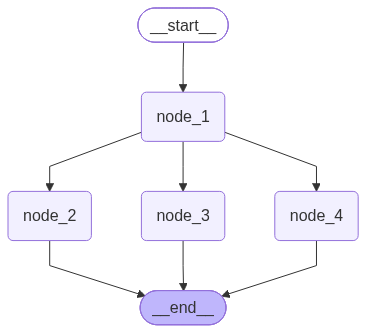

1k:logs v:['START']
1k:cur_id v:start
2k:logs v:['START', 'node_1 运行完毕']
2k:cur_id v:start
3k:logs v:['START', 'node_1 运行完毕']
3k:cur_id v:start
4k:logs v:['START', 'node_1 运行完毕']
4k:cur_id v:start
============================== -> result <- ==============================
{'logs': ['START', 'node_1 运行完毕', 'node_2 运行完毕', 'node_3 运行完毕', 'node_3 运行完毕'], 'cur_id': 'start'}


In [11]:
from sys import displayhook
from typing import TypedDict,Annotated
from operator import add
from time import sleep

from langgraph import graph
from langgraph.graph import StateGraph,START,END
from langgraph.types import Overwrite


# 1. 定义状态
class OverAllState(TypedDict):
    # 归约的方式是add追加合并
    logs:Annotated[list[str],add]
    cur_id: str


# 2. 定义节点
def node_1(state:OverAllState) -> OverAllState:
    for k,v in state.items():
        print(f"1k:{k} v:{v}")
    return {
        "logs":["node_1 运行完毕"]
    }

def node_2(state:OverAllState) -> OverAllState:
    for k,v in state.items():
        print(f"2k:{k} v:{v}")
    return {
        "logs":["node_2 运行完毕"]
    }

def node_3(state:OverAllState) -> OverAllState:
    sleep(1)
    for k,v in state.items():
        print(f"3k:{k} v:{v}")
    return {
        "logs":["node_3 运行完毕"]
    }

def node_4(state:OverAllState) -> OverAllState:
    sleep(2)  # 调控执行顺序， 先 2 再 3 最后 4
    for k,v in state.items():
        print(f"4k:{k} v:{v}")
    return {
        "logs":["node_4 运行完毕"]
    }


builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_1", node_1) # 有重载写法 见下面
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)
builder.add_node("node_4", node_4)

builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_1", "node_3") # 延迟执行，拿到还是快照1，2修改了不会影响
builder.add_edge("node_1", "node_4") # 延迟执行，拿到还是快照1，2和3修改了不会影响


graph = builder.compile()
display(graph)

result = graph.invoke({"logs": ["START"], "cur_id": "start"})
print('=' * 30, '-> result <-', '=' * 30)
print(result)


总结：
1. 快照不会因为并行节点快慢而得到上一层的结果不同
2. 如果并行执行，一定要设计reducer，不然报错（设计快慢也没有用），除非串行

这是一个非常好的问题，触及了 LangGraph `add_node` 的**重载设计**。

https://reference.langchain.com/python/langgraph/graph/state/StateGraph/add_node
### 核心答案

`add_node` 支持两种调用签名：

```python
# 签名 A：自动推导名称
add_node(node: Callable | Runnable) -> str

# 签名 B：显式指定名称
add_node(name: str, node: Callable | Runnable) -> str
```

你的两段代码分别使用了这两种签名，**都是合法的**。

---

### 逐段分析

#### 第一段代码（签名 A）
```python
builder.add_node(my_node)  # ✅ 只传了一个参数
# LangGraph 内部通过 my_node.__name__ 自动提取名称 → "my_node"
```

等价于：
```python
builder.add_node("my_node", my_node)
```

#### 第二段代码（签名 B）
```python
builder.add_node("node_1", node_1)  # ✅ 第一个参数是字符串 → 作为节点名
```

这里 `"node_1"` 就是**显式指定的节点名称**，与函数本身的 `__name__`（即 `"node_1"`）恰好相同，但即使不同也完全合法：

```python
# 这也完全可以，节点名和函数名可以不一致
builder.add_node("custom_name", node_1)
# 后续 add_edge 中要用 "custom_name" 而不是 "node_1"
```

---

### 为什么需要两种签名？

| 场景 | 推荐用法 | 原因 |
| :--- | :--- | :--- |
| 普通函数/Runnable | `add_node(func)` | 简洁，函数名即节点名 |
| lambda / 匿名函数 | `add_node("name", lambda ...)` | lambda 没有有意义的 `__name__` |
| 同一函数注册多次 | `add_node("step1", func)` + `add_node("step2", func)` | 区分同名函数的不同实例 |
| 动态生成节点名 | `add_node(f"worker_{i}", func)` | 程序化构建图时必需 |
| 类实例作为节点 | `add_node(MyNode())` 或 `add_node("name", MyNode())` | 取决于是否需要自定义名称 |

---

### ⚠️ 常见踩坑点

```python
# ❌ 错误：传了两个参数但第一个不是字符串
builder.add_node(node_1, "node_1")
# TypeError! 第一个位置参数如果是非字符串，LangGraph 会把它当作 node 对象

# ❌ 错误：自动推导名称后，用错误的名字引用
builder.add_node(my_node)       # 节点名 = "my_node"
builder.add_edge(START, "My_Node")  # ❌ 大小写不匹配，运行时报错

# ✅ 安全做法：不确定时用显式命名
builder.add_node("my_node", my_node)
builder.add_edge(START, "my_node")  # 名称明确可控
```

---

### 📌 总结

> -   **一个参数** → LangGraph 用 `func.__name__` 自动命名
> -   **两个参数且第一个是 `str`** → 该字符串就是节点名
> -   两种写法**功能完全等价**，只是命名方式不同
> -   你的第二段代码没有报错，因为 `"node_1"` 被正确识别为节点名称，这是官方支持的正式 API，不是 hack

在实际项目中，**建议始终使用显式命名**（两参数形式），这样重构函数名时不会意外破坏图的边连接。